## Building and training a CNN for image classification using the CIFAR-10 dataset

### Import libraries and data

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import random
import torch
import torch.nn
import torchvision

from torch import nn
from torchvision.transforms import ToTensor
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader
from torch.nn import CrossEntropyLoss

from timeit import default_timer as timer
from tqdm import tqdm

In [17]:
# download train dataset
train_dataset = CIFAR10(root='data',
                        train=True, 
                        transform=ToTensor(), 
                        download=True) # it will not download if it is already in root folder

# download test dataset
test_dataset = CIFAR10(root='data',
                        train=False, 
                        transform=ToTensor(), 
                        download=True) # it will not download if it is already in root folder

### Explore data

Train dataset size: 50000
Test dataset size: 10000
Number of colour channels: 3


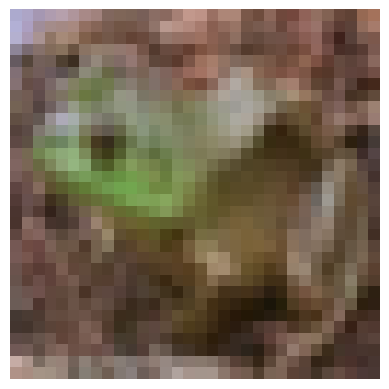

In [18]:
# set agnostic code
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# assign labels names
label_names = train_dataset.classes

# check the data
print(f'Train dataset size: {len(train_dataset)}')
print(f'Test dataset size: {len(test_dataset)}')
print(f'Number of colour channels: {len(train_dataset[0][0])}')

# choose a random index
rand_index = random.randint(0, len(train_dataset) - 1)

# function to show an image
def imshow(img):
    npimg = img.permute(1, 2, 0).numpy()
    plt.imshow(npimg)
    plt.axis(False)

# show a random picture
imshow(train_dataset[rand_index][0])

In [19]:

SEED = 42

torch.manual_seed(SEED)

# set the batch size
BATCH_SIZE = 32

# instantiate the train data loader
train_loader = DataLoader(dataset=train_dataset,
                          batch_size=BATCH_SIZE,
                          shuffle=True)

# instantiate the test data loader
test_loader = DataLoader(dataset=test_dataset,
                         batch_size=BATCH_SIZE,
                         shuffle=False)


### Build a CNN model

In [20]:
torch.cuda.manual_seed(SEED)
# model architecture definition
class Cifar10CNN(nn.Module):

    def __init__(self, input_size:int, hidden_units: int, output_size:int):
        super().__init__()
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(in_channels=input_size,
                      out_channels=hidden_units,
                      kernel_size=3,
                      padding=1,
                      stride=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                padding=1,
                stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,
                        out_channels=hidden_units,
                        kernel_size=3,
                        padding=1,
                        stride=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                padding=1,
                stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier= nn.Sequential(
            nn.Flatten(),
            nn.LazyLinear(out_features=output_size))

    def forward(self, X):
        return self.classifier(self.conv_block2(self.conv_block1(X)))

### Train the CNN model_v0

In [21]:
torch.cuda.manual_seed(SEED)

# custom function to train and test (one epoch)
def train_test_epoch(model:torch.nn.Module, loss_fn, optimizer_instance, device=device):
    """
    Trains the provided model for one epoch and tests against the test data.
    Returns train loss, test loss and accuracy.
    Args:
        - loss_fn: Instance of a loss function class.
        - optimizer_instance: Instance of an optimizer class.
    """

    ### TRAINING PHASE
    model.train() # enables Dropout/BatchNorm
    train_loss = 0

    for batch, (X, y) in enumerate(train_loader):
        X, y = X.to(device), y.to(device)

        # forward pass
        y_pred = model(X)

        # calculate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # optimizer zero_grad
        optimizer_instance.zero_grad()

        # backpropagation
        loss.backward()

        # weight update
        optimizer_instance.step()

    # average training loss for this epoch
    train_loss /= len(train_loader)


    ### TESTING PHASE
    test_loss, test_acc = 0, 0

    model.eval()
    with torch.inference_mode(): # faster, memory efficient, no gradients

        for X, y in test_loader:
            X, y = X.to(device), y.to(device)

            # forward pass
            test_preds = model(X)

            # calculate loss
            test_loss += loss_fn(test_preds, y).item()

            # calculate accuracy
            predictions = test_preds.argmax(dim=1)
            test_acc += (predictions == y).sum().item() / len(test_preds)

        # calculations for the whole test set
        test_loss /= len(test_loader)
        test_acc /= len(test_loader)
    
    return train_loss, test_loss, test_acc

In [22]:
# initiate dictionary to save model's performance
model_results = dict()

def train_test_cifar10CNN(input_size, hidden_units, output_size,
                          optimizer, lr, epochs, name, results, device=device):
    """
    Instantiates an estimator with the parameters passed as arguments.
    Train/test the estimator the number of epochs specified, timing it.

    """
    model = Cifar10CNN(input_size=input_size,
                       hidden_units=hidden_units,                       
                       output_size=output_size).to(device)

    optimizer_instance = optimizer(model.parameters(), lr=lr)

    train_loss, test_loss, acc, best_acc  = 0, 0, 0, 0
    
    start_time = timer()
    for epoch in range(epochs):
        train_loss, test_loss, acc = train_test_epoch(model, 
                                                      CrossEntropyLoss(),
                                                      optimizer_instance)
        
        best_acc = acc if acc > best_acc else best_acc
    end_time = timer()

    # obtain average of all epochs
    train_loss /= epochs
    test_loss /= epochs
    
    total_time = end_time - start_time
    time_per_epoch = total_time / epochs

    results[name] = {'hidden_units':hidden_units,
                           'optimizer':optimizer_instance.__class__.__name__,
                           'lr':lr,
                           'final_train_loss':train_loss, 
                           'final_test_loss':test_loss,
                           'final_acc':acc,
                           'best_acc':best_acc, 
                           'epochs':epochs,
                           'time_per_epoch':time_per_epoch,
                           }
    return results
    

In [23]:
### SET BASELINE MODEL
# number of epochs
EPOCHS = 7

model_results = train_test_cifar10CNN(3, 10, 10, torch.optim.SGD, 0.1,EPOCHS,
                                      'model_v0', model_results)

# display model results as a dataframe
pd.DataFrame(model_results)


,model_v0
hidden_units,10
optimizer,SGD
lr,0.1
final_train_loss,0.1672
final_test_loss,0.170775
final_acc,0.583167
best_acc,0.583167
epochs,7
time_per_epoch,9.313885


##### Comments  
Test accuracy improves at first, but then plateaus or decreases. Whereas train loss is constantly improving up to the fifth and last epoch. 
This is a classic sign of overfitting, in which the model learns the training data too well but cannot generalise well.

With only 10 hidden units, this model seems to be too simple to capture the patterns. 

A few strategies can be tried to improve performance:

- Lower learning rate
- Change the optimizer to Adam (decrease learning rate)
- Increase hidden units